# Portfolio Drift Monitor - Time Series Forecasting

**Stage 10b.** Stage 10a fitted a regression on engineered features and asked whether it
could be trusted. This notebook asks a narrower question with better machinery: given
only the drift's own history, through a proper `sklearn` Pipeline with a walk-forward
split, how well can the next month be forecast?

The answer is "slightly better than assuming nothing changes, and worse than Stage 10a".
That is a real result and the reasoning is in `docs/timeseries.md`.

**Track: time series forecasting.** Stage 10a took the regression track, so at least one
is committed as the instructions require. Classification is unavailable on this data:
Stage 08 found the flag green on all 753 fund-days, so a classifier at the 3pp threshold
has zero positive cases.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from src import features as fe
from src import modeling as md
from src import timeseries as ts
from src.utils import TARGET_WEIGHTS, AMBER_PP, RED_PP, read_df

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

RAW, PROC = Path('data/raw'), Path('data/processed')
IMG = Path('reports/images'); IMG.mkdir(parents=True, exist_ok=True)
HORIZON = 21
TICKERS = list(TARGET_WEIGHTS)

print('horizon:', HORIZON, 'trading days | thresholds: amber %.1fpp red %.1fpp'
      % (AMBER_PP, RED_PP))

horizon: 21 trading days | thresholds: amber 3.0pp red 5.0pp


## 1. Data and features

Features are built on **absolute** drift, matching the target. Section 5 measures what
happens when they are built on the signed series instead, and it is the most expensive
mistake available at this stage.

Every rolling statistic is shifted by one after its window, so a feature at row *t* uses
only rows up to *t-1*.

In [3]:
clean = sorted(PROC.glob('prices_clean_*.parquet'))
if clean:
    src_path = clean[-1]
    prices = read_df(src_path)
else:
    src_path = sorted(RAW.glob('api_yfinance_*.csv'))[-1]
    prices = pd.read_csv(src_path)
prices['date'] = pd.to_datetime(prices['date'])

panel = fe.drift_panel(prices, TARGET_WEIGHTS)
panel['abs_drift'] = panel['drift_pp'].abs()

featured, FEATURES = ts.make_lag_features(panel, col='abs_drift')
featured = ts.make_forecast_target(featured, col='abs_drift', horizon=HORIZON)
data = featured.dropna(subset=FEATURES + ['y']).reset_index(drop=True)

print('source :', src_path.name)
print('features:', ', '.join(FEATURES))
print('rows    : %d of %d after windows and the %d-day target'
      % (len(data), len(featured), HORIZON))

source : prices_clean_20260829-1718.parquet
features: lag_1, lag_5, lag_21, roll_mean_5, roll_std_5, roll_mean_21, roll_std_21, roll_min_21, roll_max_21, momentum_21, zscore_21
rows    : 624 of 753 after windows and the 21-day target


In [4]:
# The Stage 09 look-ahead audit, pointed at the Stage 10b feature builder.
def build_ts(price_frame):
    p = fe.drift_panel(price_frame, TARGET_WEIGHTS)
    p['abs_drift'] = p['drift_pp'].abs()
    out, _ = ts.make_lag_features(p, col='abs_drift')
    return out

audit = fe.assert_no_lookahead(build_ts, prices, FEATURES)
print('look-ahead audit PASSED on all %d features' % audit['features_checked'])
print('  cut %s, %d overlapping rows compared'
      % (audit['cut_date'].date(), audit['rows_compared']))

look-ahead audit PASSED on all 11 features
  cut 2026-05-12, 528 overlapping rows compared


## 2. Split and Pipeline

Time-aware split, cut on dates. The Pipeline is the Stage 10b requirement, and the reason
is narrow: `fit` fits the scaler on the training rows only. Stage 10a deliberately did not
scale, because scaling before a split fits on rows the test set will contain, and the
Stage 09 look-ahead audit cannot catch that because it happens after the features are
built.

In [5]:
train, test, cut = ts_split = md.chronological_split(data, test_frac=0.2)
print('cut   :', cut.date())
print('train : %d rows, target mean %.3f' % (len(train), train['y'].mean()))
print('test  : %d rows, target mean %.3f' % (len(test), test['y'].mean()))
print()

COLS = ['lag_1', 'zscore_21']
pipe = ts.build_pipeline(model=Ridge(alpha=1.0)).fit(train[COLS], train['y'])
print(pipe)
print()

leaky_scaler = StandardScaler().fit(data[COLS])
leaky = Ridge(alpha=1.0).fit(leaky_scaler.transform(train[COLS]), train['y'])

leak_table = pd.DataFrame([
    {'approach': 'scaler inside Pipeline (correct)',
     **ts.evaluate_forecast(test['y'], pipe.predict(test[COLS]))},
    {'approach': 'scaler fitted on all rows (leaky)',
     **ts.evaluate_forecast(test['y'],
                            leaky.predict(leaky_scaler.transform(test[COLS])))},
]).set_index('approach').round(5)
display(leak_table)

print('scaler means, train-only vs all-rows:')
print(pd.DataFrame({'train_only': pipe.named_steps['scaler'].mean_,
                    'all_rows': leaky_scaler.mean_}, index=COLS).round(4).to_string())

cut   : 2026-06-01
train : 498 rows, target mean 0.729
test  : 126 rows, target mean 1.033

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])



,mae,rmse,r2,n
approach,,,,
scaler inside Pipeline (correct),0.2287,0.27318,0.57740,126
scaler fitted on all rows (leaky),0.2287,0.27319,0.57738,126


scaler means, train-only vs all-rows:
           train_only  all_rows
lag_1          0.6292    0.6902
zscore_21      0.2954    0.2431


**The leak costs 0.00001 RMSE here, and the reason is worth knowing.**

It is not that the leaked statistics are similar. `lag_1` centres at 0.629 on the training
rows and 0.690 across all rows, a 10% difference, because the test period runs higher. The
leaked information is genuinely different and the forecast still does not move.

Standardising is an affine transformation, and a linear model absorbs an affine change of
its inputs into its coefficients almost exactly. Ridge's penalty applies to the scaled
coefficients, so a trace survives, and that trace is the 0.00001.

So the Pipeline here is a correctness guarantee that costs nothing rather than a
performance trick. Swap the estimator for a tree ensemble or anything distance-based and
the same leak stops being free, with no change to how the code is written. That is the
argument for making it structural.

## 3. Walk-forward cross-validation, and honest selection

Seven feature sets, ranked by walk-forward CV on the **training data only**, then checked
against the test set. That order matters: selecting on the test score and then reporting
it produces a number nobody can reproduce.

In [6]:
FEATURE_SETS = {
    'lag_1 only':               ['lag_1'],
    'lag_1 + lag_5':            ['lag_1', 'lag_5'],
    'lag_1 + zscore_21':        ['lag_1', 'zscore_21'],
    'lag_1 + roll_mean_21':     ['lag_1', 'roll_mean_21'],
    'lag_1 + momentum_21':      ['lag_1', 'momentum_21'],
    'lag_1 + mean_21 + std_21': ['lag_1', 'roll_mean_21', 'roll_std_21'],
    'all 11 features':          FEATURES,
}
sweep = ts.sweep_feature_sets(train, test, 'y', FEATURE_SETS)
display(sweep)

cv_choice = sweep.index[0]
print('CV-selected (train only)      :', cv_choice)
print('best on test (not a criterion):', sweep['test_rmse'].idxmin())

/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

,n_features,cv_rmse,cv_std,test_rmse,test_mae,test_r2
lag_1 only,1.0,0.4666,0.1067,0.2857,0.2390,0.5376
lag_1 + lag_5,2.0,0.4739,0.0993,0.2833,0.2375,0.5454
lag_1 + zscore_21,2.0,0.4745,0.1104,0.2732,0.2287,0.5774
lag_1 + roll_mean_21,2.0,0.4915,0.0888,0.2740,0.2296,0.5749
lag_1 + momentum_21,2.0,0.5025,0.0871,0.2882,0.2410,0.5297
lag_1 + mean_21 + std_21,3.0,0.6114,0.3347,0.3724,0.2931,0.2148
all 11 features,11.0,0.7463,0.5452,0.4087,0.3226,0.0540


CV-selected (train only)      : lag_1 only
best on test (not a criterion): lag_1 + zscore_21


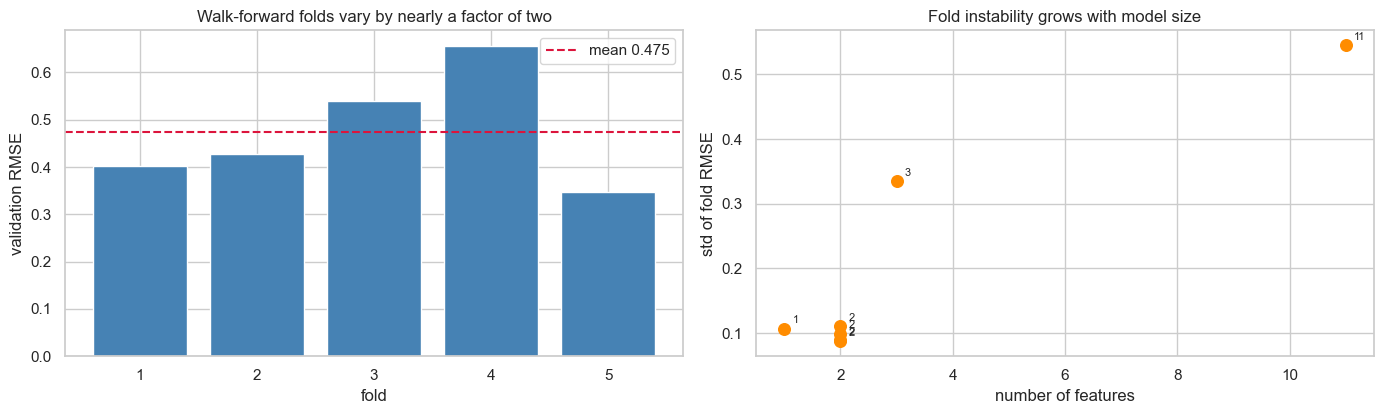

fold RMSE: [0.401 0.428 0.54  0.656 0.347]
mean 0.475, sd 0.110


In [7]:
cv = ts.time_series_cv(ts.build_pipeline(), train[COLS], train['y'], n_splits=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
axes[0].bar(range(1, 6), cv['fold_rmse'], color='steelblue')
axes[0].axhline(cv['mean_rmse'], color='crimson', linestyle='--',
                label='mean %.3f' % cv['mean_rmse'])
axes[0].set_xlabel('fold'); axes[0].set_ylabel('validation RMSE')
axes[0].set_title('Walk-forward folds vary by nearly a factor of two')
axes[0].legend()

axes[1].scatter(sweep['n_features'], sweep['cv_std'], s=70, color='darkorange')
for name, row in sweep.iterrows():
    axes[1].annotate(f"{row['n_features']:.0f}", (row['n_features'], row['cv_std']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)
axes[1].set_xlabel('number of features'); axes[1].set_ylabel('std of fold RMSE')
axes[1].set_title('Fold instability grows with model size')

fig.tight_layout()
fig.savefig(IMG / 'ts_cross_validation.png', dpi=110, bbox_inches='tight')
plt.show()

print('fold RMSE:', np.round(cv['fold_rmse'], 3))
print('mean %.3f, sd %.3f' % (cv['mean_rmse'], cv['std_rmse']))

**The spread is the result.** Five folds give validation RMSE from 0.347 to 0.656 around a
mean of 0.475, a standard deviation of 0.110. That is the Stage 10a effective sample size
problem seen from a different angle: with roughly 24 independent observations, which 80%
of the window a model trains on genuinely changes what it learns.

**CV and the test set agree on the ranking**, which is the evidence that running CV was
worth it. All eleven features give CV RMSE 0.746 with a fold sd of 0.545 and test RMSE
0.409; one feature gives 0.467, sd 0.107, and test 0.286. CV would have rejected the large
model without anyone touching the test data.

**The selection is the simplest model.** CV picks `lag_1` alone. On test,
`lag_1 + zscore_21` is better by 0.013 RMSE, which is a tenth of the fold standard
deviation. The two are indistinguishable, and preferring the simpler one is the
disciplined call rather than chasing the test set.

## 4. Results against the baselines that matter

In [8]:
FINAL = FEATURE_SETS[cv_choice]
final_pipe = ts.build_pipeline().fit(train[FINAL], train['y'])
pred = final_pipe.predict(test[FINAL])

signed_panel, SIGNED = ts.make_lag_features(panel, col='drift_pp')
signed_panel = ts.make_forecast_target(signed_panel, col='abs_drift', horizon=HORIZON)
sdata = signed_panel.dropna(subset=SIGNED + ['y']).reset_index(drop=True)
str_, ste_, _ = md.chronological_split(sdata, test_frac=0.2)
wrong = ts.build_pipeline().fit(str_[SIGNED], str_['y'])

board = pd.DataFrame([
    {'predictor': f'pipeline, {cv_choice}', **ts.evaluate_forecast(test['y'], pred)},
    {'predictor': 'pipeline, all 11 features',
     **ts.evaluate_forecast(test['y'], ts.build_pipeline()
                            .fit(train[FEATURES], train['y']).predict(test[FEATURES]))},
    {'predictor': 'persistence (no model)',
     **ts.evaluate_forecast(test['y'], ts.persistence_forecast(test))},
    {'predictor': 'train mean (flat line)',
     **ts.evaluate_forecast(test['y'], np.full(len(test), train['y'].mean()))},
    {'predictor': 'SIGNED-space features (wrong space)',
     **ts.evaluate_forecast(ste_['y'], wrong.predict(ste_[SIGNED]))},
]).set_index('predictor').round(4)
board

/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

,mae,rmse,r2,n
predictor,,,,
"pipeline, lag_1 only",0.2390,0.2857,0.5376,126
"pipeline, all 11 features",0.3226,0.4087,0.0540,126
persistence (no model),0.2392,0.2947,0.5081,126
train mean (flat line),0.4024,0.5187,-0.5235,126
SIGNED-space features (wrong space),0.5112,0.7405,-2.1050,126


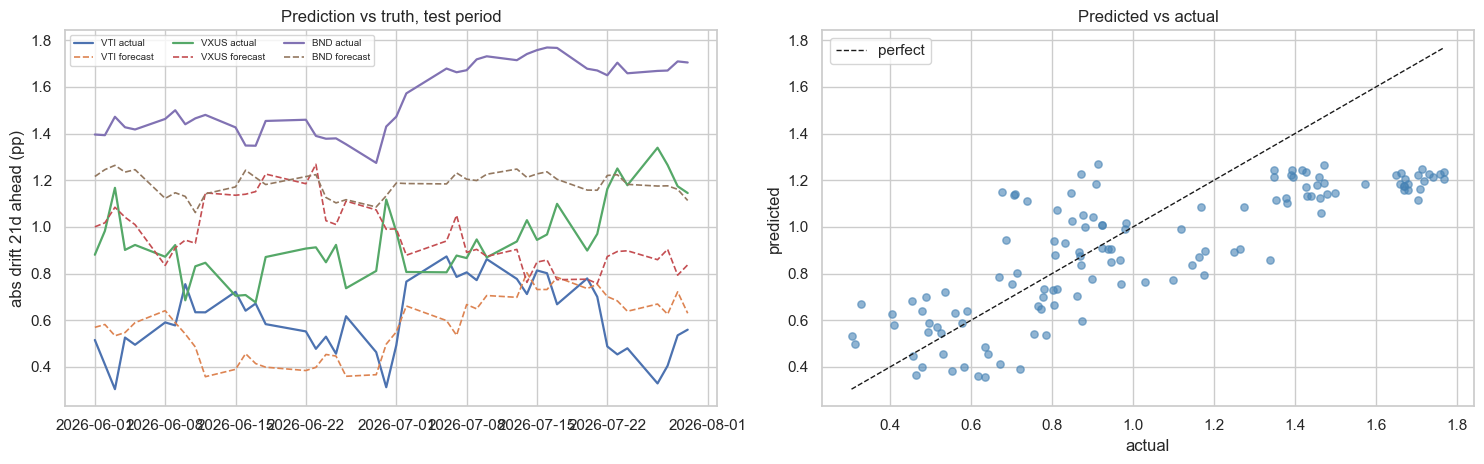

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

for t in TICKERS:
    m_ = (test['ticker'] == t).to_numpy()
    axes[0].plot(test['date'][m_], test['y'][m_], linewidth=1.6, label=f'{t} actual')
    axes[0].plot(test['date'][m_], pred[m_], linewidth=1.2, linestyle='--',
                 label=f'{t} forecast')
axes[0].set_title('Prediction vs truth, test period')
axes[0].set_ylabel('abs drift 21d ahead (pp)')
axes[0].legend(ncol=3, fontsize=7)

axes[1].scatter(test['y'], pred, alpha=0.6, s=28, color='steelblue')
lims = [min(test['y'].min(), pred.min()), max(test['y'].max(), pred.max())]
axes[1].plot(lims, lims, 'k--', linewidth=1, label='perfect')
axes[1].set_xlabel('actual'); axes[1].set_ylabel('predicted')
axes[1].set_title('Predicted vs actual')
axes[1].legend()

fig.tight_layout()
fig.savefig(IMG / 'ts_prediction_vs_truth.png', dpi=110, bbox_inches='tight')
plt.show()

**Three findings.**

**The wrong feature space is catastrophic.** Same eleven features, same pipeline, same
split, built on signed drift instead of absolute: RMSE 0.741 against 0.286, R² **-2.11**,
far worse than predicting a constant at -0.52. BND's drift sits negative and VXUS's
positive, so a linear model given signed lags cannot represent an absolute target across
funds. No amount of pipeline hygiene rescues a model pointed at the wrong quantity.

**The prescribed feature family adds almost nothing.** MAE 0.239pp and RMSE 0.286pp
against persistence at 0.295pp: a **3% improvement**. Lags, rolling statistics, extremes,
momentum and z-scores are the standard toolkit, and on this series they recover the naive
baseline and little more.

**Stage 10a's engineered features beat all of them.** 0.211pp against 0.286pp, 26% better.
The features that carry signal here came from *domain reasoning* rather than from the
series' own history: drift relative to its fund's target, the rolling slope of the trend,
realized volatility, fund identity. On this problem, Stage 09's approach outperforms
Stage 10b's, and that comparison is the most useful thing this notebook produced.

## 5. Save

In [10]:
import datetime as dt
stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

sweep.to_csv(PROC / f'ts_feature_sweep_{stamp}.csv')
board.to_csv(PROC / f'ts_vs_baselines_{stamp}.csv')

preds = test[['date', 'ticker', 'y']].copy()
preds['predicted'] = pred
preds['residual'] = preds['y'] - preds['predicted']
preds.to_csv(PROC / f'ts_test_predictions_{stamp}.csv', index=False)

for p in sorted(PROC.glob(f'ts_*{stamp}*')):
    print('%-46s %7d bytes' % (p.name, p.stat().st_size))
print()
for p in sorted(IMG.glob('ts_*.png')):
    print('%-46s %7d bytes' % (p.name, p.stat().st_size))

ts_feature_sweep_20260829-1733.csv                 449 bytes
ts_test_predictions_20260829-1733.csv             9249 bytes
ts_vs_baselines_20260829-1733.csv                  281 bytes

ts_cross_validation.png                          37748 bytes
ts_prediction_vs_truth.png                      133642 bytes


## 6. What this means for the monitor

**What Stage 10b adds.** Not a better forecast. Better *machinery*: a Pipeline that makes
train-only fitting structural, a walk-forward split that never trains on the future, and
a selection made on cross-validation rather than on the test set. Stage 10a's numbers are
now the ones to beat, and they were produced without any of this discipline, so they
deserve to be re-checked under it in Stage 11.

**What it says about the data.** The drift's own history contains one useful fact, which
is where the drift is today. Everything after that is noise at this sample size. The
signal lives in the structural features Stage 09 built from domain reasoning.

**For Dana.** No change to what the report can say. The forecast is still a magnitude, not
a breach date, and the model still has never seen an exceedance.

**Assumptions that break, unchanged from Stage 10a**

| Assumption | Status |
|---|---|
| Observations independent | **False.** 21-day overlapping targets, about 24 effective observations. Every fold swing above is that shortage. |
| Relationship stable over time | Untested and probably false. One trending year, and Stage 08 found a ratchet rather than a stationary process. |
| Constant error variance | False. Residuals grow with the prediction, matching Stage 10a's 1.16 ratio. |
| Features available when the prediction is made | **True, and tested** by the look-ahead audit. |

**Into Stage 11.** Evaluation under uncertainty: bootstrap the intervals that Stage 10a
could not honestly quote, compare scenarios, and test whether the subgroups (the three
funds) behave differently enough to need separate treatment. The fold spread here is the
first evidence that they might.